In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import numpy as np
from tslearn.datasets import UCR_UEA_datasets
from sklearn.linear_model import RidgeClassifierCV
from aeon.transformations.collection.convolution_based import Rocket
from src.preprocessing import scale_lsst_data, encode_lsst_labels
import torch
from torch.utils.data import DataLoader
from src.dataset import LSSTClassificationDataset
from src.model import TimeSeriesEncoderCI, ClassificationModel

## Baseline (ROCKET)

In [6]:
def plot_normalized_cm(y_true, y_pred, class_names, title="Normalized Confusion Matrix", save_path=None):
    """
    Trace une matrice de confusion normalisée, parfaite pour les rapports académiques.
    """
    # Calcul de la matrice normalisée (les lignes s'additionnent à 1)
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    
    # Configuration de la figure (style académique)
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="white") # Fond blanc épuré
    
    # Création de la heatmap
    ax = sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                     xticklabels=class_names, yticklabels=class_names,
                     cbar_kws={'label': 'Proportion of True Class'},
                     vmin=0.0, vmax=1.0) # Force l'échelle de couleurs de 0 à 100%
    
    plt.title(title, fontsize=14, pad=20, fontweight='bold')
    plt.ylabel('True Astronomical Class', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted Astronomical Class', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()        
    plt.show()

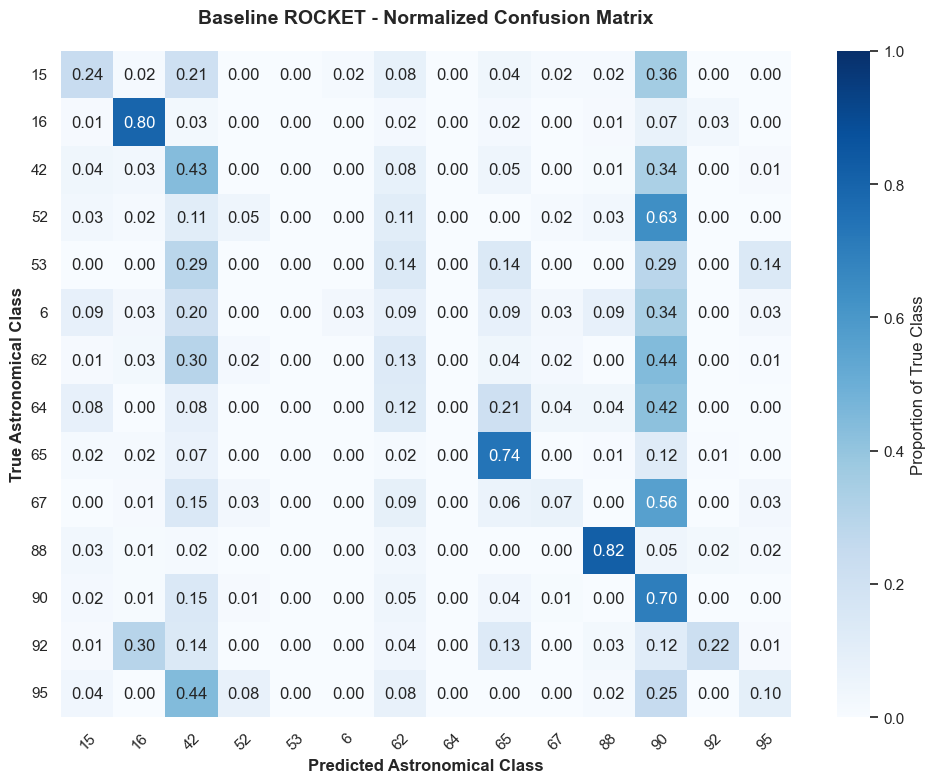

In [7]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

X_train_scaled, X_test_scaled = scale_lsst_data(X_train, X_test)
y_train_encoded, y_test_encoded, label_encoder = encode_lsst_labels(y_train, y_test)

X_train_aeon = np.transpose(X_train_scaled, (0, 2, 1))
X_test_aeon = np.transpose(X_test_scaled, (0, 2, 1))

rocket = Rocket(n_kernels=10000, random_state=42)
X_train_features = rocket.fit_transform(X_train_aeon)
X_test_features = rocket.transform(X_test_aeon)

classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
classifier.fit(X_train_features, y_train_encoded)

y_pred_baseline = classifier.predict(X_test_features)

class_names = label_encoder.classes_
plot_normalized_cm(y_test_encoded, y_pred_baseline, class_names, title="Baseline ROCKET - Normalized Confusion Matrix", save_path="baseline_cm.pdf")

## Setting 2 


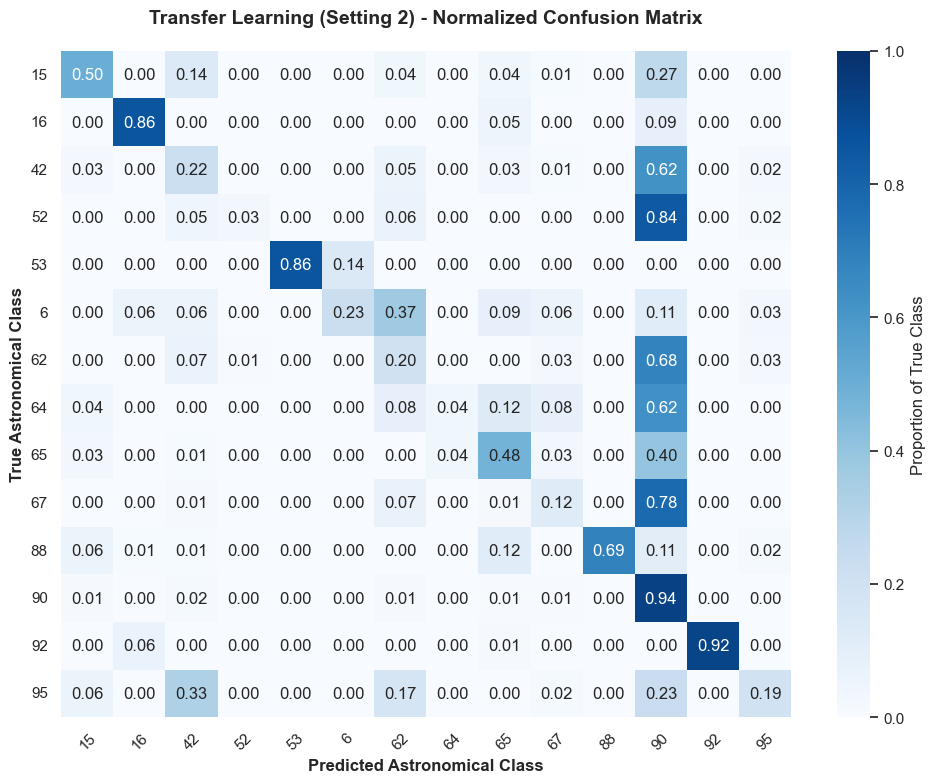

In [10]:
# On utilise X_test_scaled et y_test_encoded qui ont été générés dans la Cellule 2
test_dataset = LSSTClassificationDataset(X_test_scaled, y_test_encoded)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

hidden_dim = 64
num_channels = X_test_scaled.shape[2]
num_classes = len(np.unique(y_test_encoded))

# On recrée l'architecture exacte (Encodeur + Tête de classification)
encoder = TimeSeriesEncoderCI(hidden_dim=hidden_dim)
model_dl = ClassificationModel(encoder, num_channels=num_channels, num_classes=num_classes)


# On charge le modèle complet qui a été entraîné par finetune.py
model_dl.load_state_dict(torch.load("best_classification_model.pth"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_dl.to(device)
model_dl.eval() # On passe le modèle en mode "évaluation" (désactive le dropout, etc.)


y_pred_dl = []

# Désactivation du calcul des gradients pour accélérer l'inférence
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        outputs = model_dl(batch_x)
        
        # On récupère la classe qui a la probabilité maximale
        _, predicted = torch.max(outputs.data, 1)
        y_pred_dl.extend(predicted.cpu().numpy())

# Appel de notre fonction magique définie dans la Cellule 1
plot_normalized_cm(
    y_true=y_test_encoded, 
    y_pred=y_pred_dl, 
    class_names=class_names, 
    title="Transfer Learning (Setting 2) - Normalized Confusion Matrix",
    save_path="cm_deep_learning.pdf"
)